In [1]:
import scanpy as sc
import pandas as pd

adata_dr = sc.read_h5ad("MergedSCEs_Healthy_GSM4085625_GSE137720_CCl4_6w_HSCs.h5ad")

c:\Users\selim\miniconda3\envs\scanpy_env_311\Lib\site-packages\scanpy\_utils\__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
c:\Users\selim\miniconda3\envs\scanpy_env_311\Lib\site-packages\scanpy\__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
c:\Users\selim\miniconda3\envs\scanpy_env_311\Lib\site-packages\scanpy\readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
c:\Users\selim\miniconda3\envs\scanpy_env_311\Lib\site-packages\anndata\_core\anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


## Step 1 — Browse available pathway libraries and find your pathway
Use `browse_pathways()` to preview what's available **before** running the pipeline.

In [2]:
adata_dr.layers["counts"] = adata_dr.X.copy()
# Normalizing to median total counts
sc.pp.normalize_total(adata_dr)
# Logarithmize the data
sc.pp.log1p(adata_dr)

adata_dr

AnnData object with n_obs × n_vars = 12301 × 12461
    obs: 'cell_type', 'batch_id', 'cluster'
    uns: 'log1p'
    obsm: 'X_umap'
    layers: 'counts'

c:\Users\selim\miniconda3\envs\scanpy_env_311\Lib\site-packages\scanpy\preprocessing\_pca.py:206: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  Version(ad.__version__) < Version("0.9")
c:\Users\selim\miniconda3\envs\scanpy_env_311\Lib\site-packages\scanpy\neighbors\__init__.py:423: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  if "X_diffmap" in adata.obsm_keys():
C:\Users\selim\AppData\Local\Temp\ipykernel_52324\3431160989.py:6: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_dr, flavor="leidenalg", n_iterations=2, resolution=1.0)


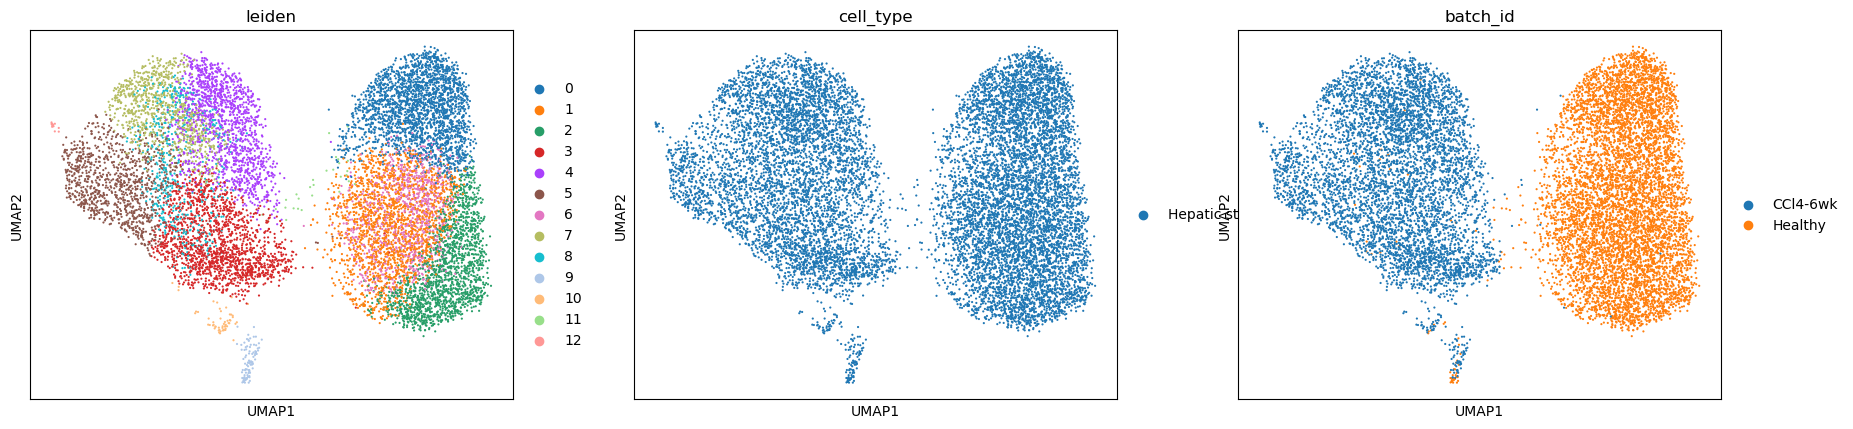

In [3]:
# process to visualize
sc.pp.highly_variable_genes(adata_dr, n_top_genes=2000)
sc.tl.pca(adata_dr, n_comps=50, svd_solver="arpack")
sc.pp.neighbors(adata_dr, n_neighbors=15)
sc.tl.umap(adata_dr, n_components=2)
sc.tl.leiden(adata_dr, flavor="leidenalg", n_iterations=2, resolution=1.0)

# Using the igraph implementation and a fixed number of iterations can be significantly faster,
# especially for larger datasets
sc.pl.umap(adata_dr, color=["leiden", "cell_type", "batch_id"])


In [4]:
from qubo_dr.pathway import browse_pathways, preview_pathway_genes, list_enrichr_libraries

# ── List available libraries (filter by keyword) ───────────────────────────
print("=== Libraries containing 'KEGG' ===")
print(list_enrichr_libraries('KEGG'))

print("\n=== Libraries containing 'GO_Biological' ===")
print(list_enrichr_libraries('GO_Biological'))

print("\n=== Libraries containing 'Reactome' ===")
print(list_enrichr_libraries('Reactome'))

print("\n=== Libraries containing 'GO_Molecular_Function' ===")
print(list_enrichr_libraries('GO_Molecular_Function'))

=== Libraries containing 'KEGG' ===
['KEGG_2013', 'KEGG_2015', 'KEGG_2016', 'KEGG_2019_Human', 'KEGG_2019_Mouse', 'KEGG_2021_Human', 'KEGG_2026']

=== Libraries containing 'GO_Biological' ===
['GO_Biological_Process_2021', 'GO_Biological_Process_2023', 'GO_Biological_Process_2025', 'GO_Biological_Process_2026']

=== Libraries containing 'Reactome' ===
['Reactome_2022', 'Reactome_Pathways_2024']

=== Libraries containing 'GO_Molecular_Function' ===
['GO_Molecular_Function_2021', 'GO_Molecular_Function_2023', 'GO_Molecular_Function_2025', 'GO_Molecular_Function_2026']


In [28]:
# ── Browse via Enrichr libraries (offline, no rate limit) ─────────────────
browse_pathways('Transforming growth factor beta receptor signaling', organism='human', libraries=['GO_Biological_Process_2026', 'GO_Molecular_Function_2026',  'Reactome_Pathways_2024'], 
                show_genes=True, max_results=20)


[GO_Biological_Process_2026  —  matches for 'Transforming growth factor beta receptor signaling']
  [  84 genes]  Negative Regulation of Transforming Growth Factor Beta Receptor Signaling Pathway (GO:0030512)
             → ADAM17, ADAMTSL2, ARID4A, ARID4B, ASPN, BAMBI, BCL9L, BMP2, BRMS1, BRMS1L ...
  [  26 genes]  Positive Regulation of Transforming Growth Factor Beta Receptor Signaling Pathway (GO:0030511)
             → ADISSP, CDKN1C, CDKN2B, CITED1, CITED2, CREBBP, EP300, FLCN, GIPC1, HIPK2 ...
  [ 126 genes]  Regulation of Transforming Growth Factor Beta Receptor Signaling Pathway (GO:0017015)
             → ADAM17, ADAMTSL2, ADISSP, ARID4A, ARID4B, ASPN, BAMBI, BCL9, BCL9L, BMP2 ...
  [  79 genes]  Transforming Growth Factor Beta Receptor Signaling Pathway (GO:0007179)
             → ACVR1, ACVRL1, ADAM9, APOA1, APPL1, APPL2, ARRB2, BAMBI, BMPR1A, CDH5 ...

→ 4 total match(es) across 1 librar(ies).
  Copy the exact term name and pass it to get_pathway_genes() or preview_pathwa

{'GO_Biological_Process_2026': {'Negative Regulation of Transforming Growth Factor Beta Receptor Signaling Pathway (GO:0030512)': ['ADAM17',
   'ADAMTSL2',
   'ARID4A',
   'ARID4B',
   'ASPN',
   'BAMBI',
   'BCL9L',
   'BMP2',
   'BRMS1',
   'BRMS1L',
   'CD109',
   'CDH3',
   'CIDEA',
   'CILP',
   'DAND5',
   'EID2',
   'EMILIN1',
   'ENG',
   'FAM89B',
   'FBN1',
   'FBN2',
   'FKBP1A',
   'GDF15',
   'HDAC1',
   'HDAC2',
   'HSPA1A',
   'HTRA3',
   'HTRA4',
   'IL17RD',
   'ING1',
   'ING2',
   'INTS9',
   'LDLRAD4',
   'LEMD3',
   'LRRC32',
   'MECOM',
   'MTMR4',
   'NKX2-1',
   'OGT',
   'OVOL2',
   'PBLD',
   'PDPK1',
   'PEG10',
   'PIN1',
   'PMEPA1',
   'PPARA',
   'PPARG',
   'PPM1A',
   'PRDM16',
   'RBBP4',
   'RBBP7',
   'SAP130',
   'SAP30',
   'SAP30L',
   'SIN3A',
   'SINHCAF',
   'SIRT1',
   'SKI',
   'SKIL',
   'SKOR2',
   'SLC2A10',
   'SMAD6',
   'SMAD7',
   'SMURF1',
   'SMURF2',
   'SNX25',
   'SNX6',
   'SPRED1',
   'SPRED2',
   'SPRED3',
   'SPRY1',
   'SPRY2

In [29]:
# ── Preview the full gene list for a specific pathway ─────────────────────
pathway_target = 'Transforming Growth Factor Beta Receptor Signaling Pathway'
lib_target = 'GO_Biological_Process_2026'
pathway_genes = preview_pathway_genes(pathway_target, organism='mouse', library=lib_target)
print(f"\nTotal: {len(pathway_genes)} genes")

  Found 'Negative Regulation of Transforming Growth Factor Beta Receptor Signaling Pathway (GO:0030512)'
  Library: [GO_Biological_Process_2026]  |  Genes: 84

[GO_Biological_Process_2026  —  'Transforming Growth Factor Beta Receptor Signaling Pathway']  84 genes:
  ADAM17      ADAMTSL2    ARID4A      ARID4B      ASPN        BAMBI     
  BCL9L       BMP2        BRMS1       BRMS1L      CD109       CDH3      
  CIDEA       CILP        DAND5       EID2        EMILIN1     ENG       
  FAM89B      FBN1        FBN2        FKBP1A      GDF15       HDAC1     
  HDAC2       HSPA1A      HTRA3       HTRA4       IL17RD      ING1      
  ING2        INTS9       LDLRAD4     LEMD3       LRRC32      MECOM     
  MTMR4       NKX2-1      OGT         OVOL2       PBLD        PDPK1     
  PEG10       PIN1        PMEPA1      PPARA       PPARG       PPM1A     
  PRDM16      RBBP4       RBBP7       SAP130      SAP30       SAP30L    
  SIN3A       SINHCAF     SIRT1       SKI         SKIL        SKOR2     
  SLC

In [30]:
from pprint import pprint
pprint(pathway_genes, compact=True, width=177)

['ADAM17', 'ADAMTSL2', 'ARID4A', 'ARID4B', 'ASPN', 'BAMBI', 'BCL9L', 'BMP2', 'BRMS1', 'BRMS1L', 'CD109', 'CDH3', 'CIDEA', 'CILP', 'DAND5', 'EID2', 'EMILIN1', 'ENG', 'FAM89B',
 'FBN1', 'FBN2', 'FKBP1A', 'GDF15', 'HDAC1', 'HDAC2', 'HSPA1A', 'HTRA3', 'HTRA4', 'IL17RD', 'ING1', 'ING2', 'INTS9', 'LDLRAD4', 'LEMD3', 'LRRC32', 'MECOM', 'MTMR4', 'NKX2-1',
 'OGT', 'OVOL2', 'PBLD', 'PDPK1', 'PEG10', 'PIN1', 'PMEPA1', 'PPARA', 'PPARG', 'PPM1A', 'PRDM16', 'RBBP4', 'RBBP7', 'SAP130', 'SAP30', 'SAP30L', 'SIN3A', 'SINHCAF', 'SIRT1',
 'SKI', 'SKIL', 'SKOR2', 'SLC2A10', 'SMAD6', 'SMAD7', 'SMURF1', 'SMURF2', 'SNX25', 'SNX6', 'SPRED1', 'SPRED2', 'SPRED3', 'SPRY1', 'SPRY2', 'STRAP', 'STUB1', 'SUDS3', 'TET1',
 'USP15', 'VASN', 'VEPH1', 'WFIKKN1', 'WFIKKN2', 'XBP1', 'ZBTB7A', 'ZNF451']


## Step 2 — Run DR-QUBO on Kong2023 (Crohn's disease) stem cells

In [15]:
adata_dr

AnnData object with n_obs × n_vars = 2540 × 13281
    obs: 'cell_type', 'batch_id', 'cluster', 'leiden'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'cell_type_colors', 'batch_id_colors'
    obsm: 'X_umap', 'X_pca'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [ ]:
import numpy as np
from scipy.sparse import issparse
from qubo_dr.pipeline import run_pipeline
from qubo_dr.pathway import preview_pathway_genes

# Extract matrix and gene symbols
# Note: var_names in this dataset are Ensembl IDs — use var['gene_symbols'] for pathway matching
# For datasets where var_names ARE already gene symbols, use: g_cd = list(adata_dr.var_names)
X_cd     = adata_dr.X.toarray().T if issparse(adata_dr.X) else adata_dr.X.T  # → genes × cells
g_cd     = list(adata_dr.var_names)
batch_cd = adata_dr.obs['batch_id'].values  
test_label = 'CCl4-6wk'
reference_label = 'Healthy' 

print(f"Adypocyte diet study: {(batch_cd == test_label).sum()} | WT control: {(batch_cd == reference_label).sum()}")
print(f"Matrix shape (genes × cells): {X_cd.shape}")
print(f"Gene name example: {g_cd[:5]}")

Adypocyte diet study: 641 | WT control: 1899
Matrix shape (genes × cells): (13281, 2540)
Gene name example: ['Gnai3', 'Cdc45', 'Scml2', 'Apoh', 'Narf']


Fetching pathway 'PPAR SIGNALING PATHWAY' [KEGG_2026]
  Found 'PPAR SIGNALING PATHWAY'
  Library: [KEGG_2026]  |  Genes: 76
  76 genes retrieved
Pathway genes in data: 51/76
Partitioning: 'HFD' (test/A) vs 'LFD' (reference/B)
  Test (A): 641 cells | Reference (B): 1899 cells
Computing cosine similarity matrices...
Computing differential co-expression (dS = S_ref − S_test)...
  V_diff term: disabled (no cell-state scalar provided)
Building MNN adjacency matrices (SVD d=50)...
Pathway prior X_net: skipped (pure pathway-gene analysis — prior would be a uniform constant with no effect)
Assembling QUBO matrix...
  Penalty (spectral): ||Q1||_2=59.6073 → P=119.2145 (scale=2)
QUBO assembled: 51×51 | penalty P=119.2145 | K=20
Solving QUBO (SteepestDescent (classical), 1000 reads)...
  Selected 20 genes (target K=20) | energy=-48460.2509
  Saved 20 genes to qubo_genes_pparg.txt
Hub significance test (200 permutations)...
  Hub permutation test: 200 perms, K=20 genes, N=2540 cells…
  E_real=-14.4

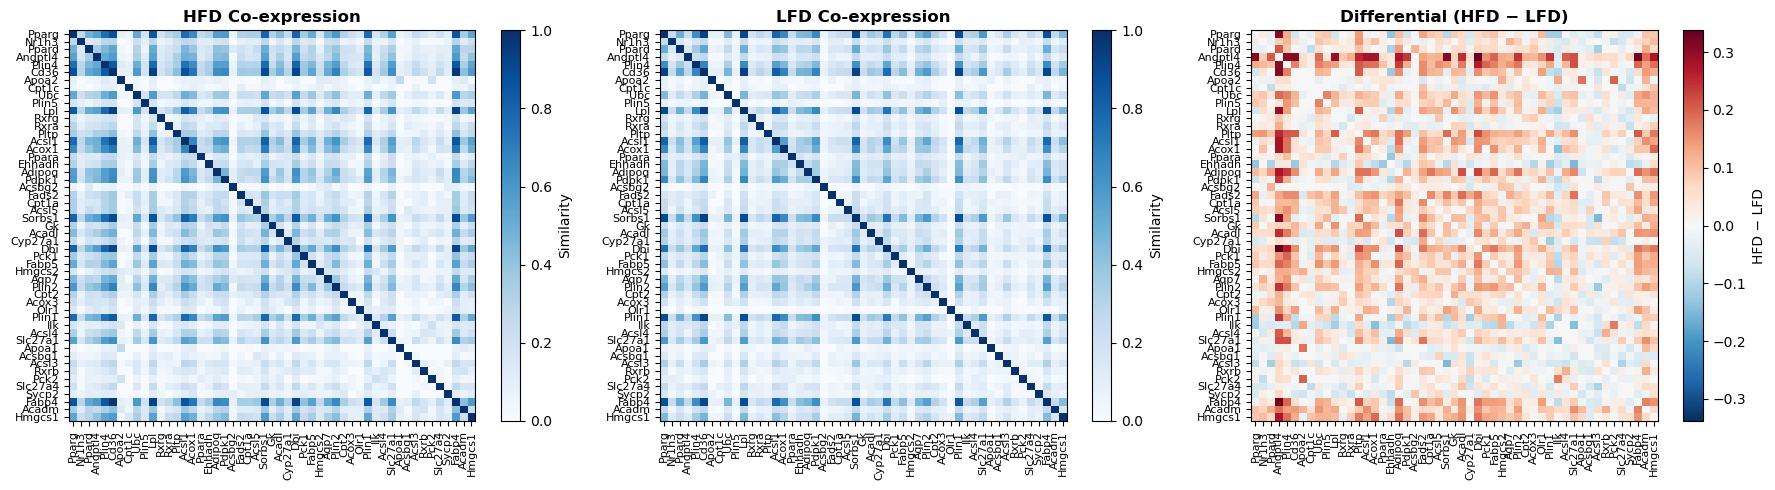

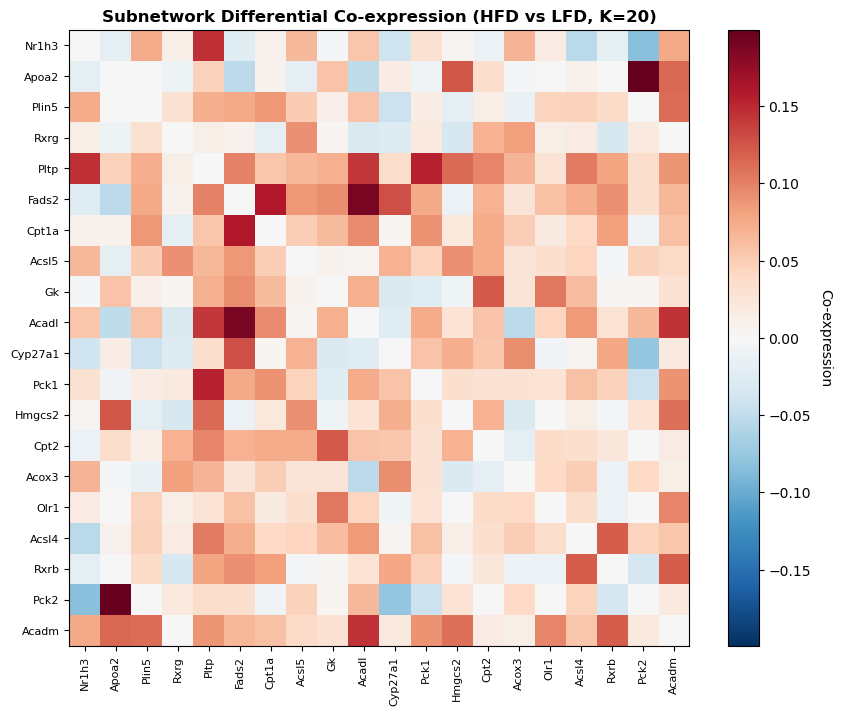

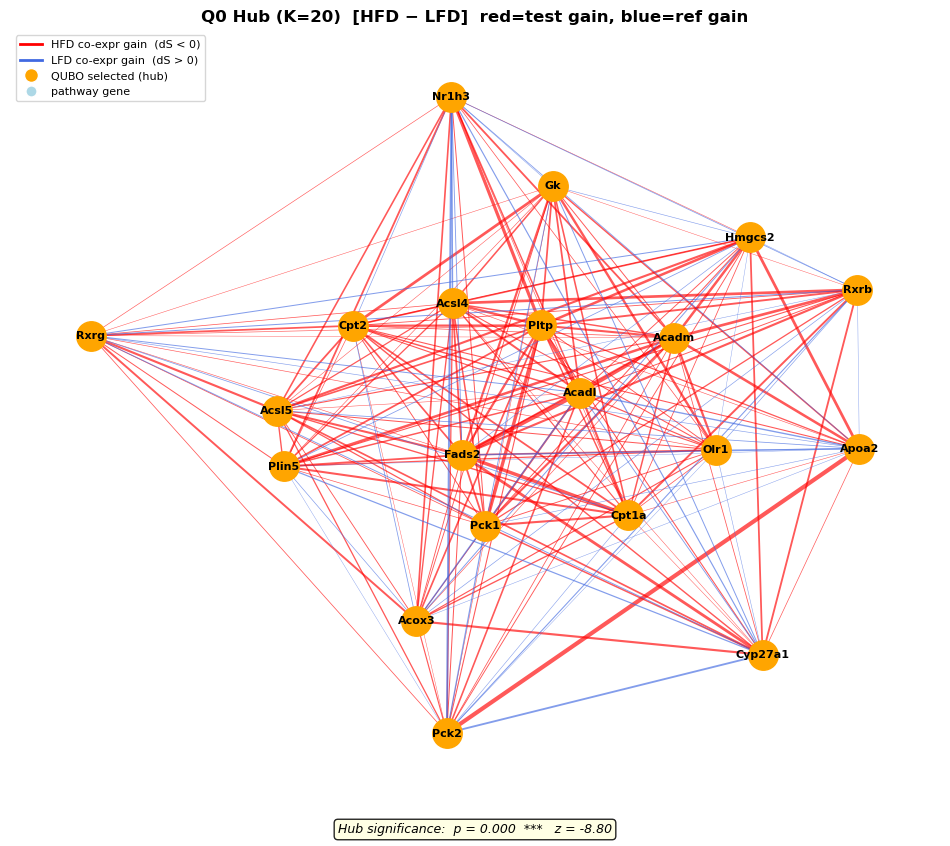

In [ ]:
results_cd = run_pipeline(
    X               = X_cd,
    g               = g_cd,
    batch_id        = batch_cd,
    test_label      = test_label,      # condition A
    reference_label = reference_label,      # condition B (reference)
    pathway_name    = pathway_target,
    library         = lib_target,    # optional: restricts search to one library (faster)
    K               = 20,
    num_reads       = 1000,
    solver          = 'sd',
    plotit          = True,
    outfile         = 'qubo_genes_TGFb.txt',
)

print(f"\n── Selected pathway {pathway_target} subnetwork ──")
print(results_cd['sub_g_net'])

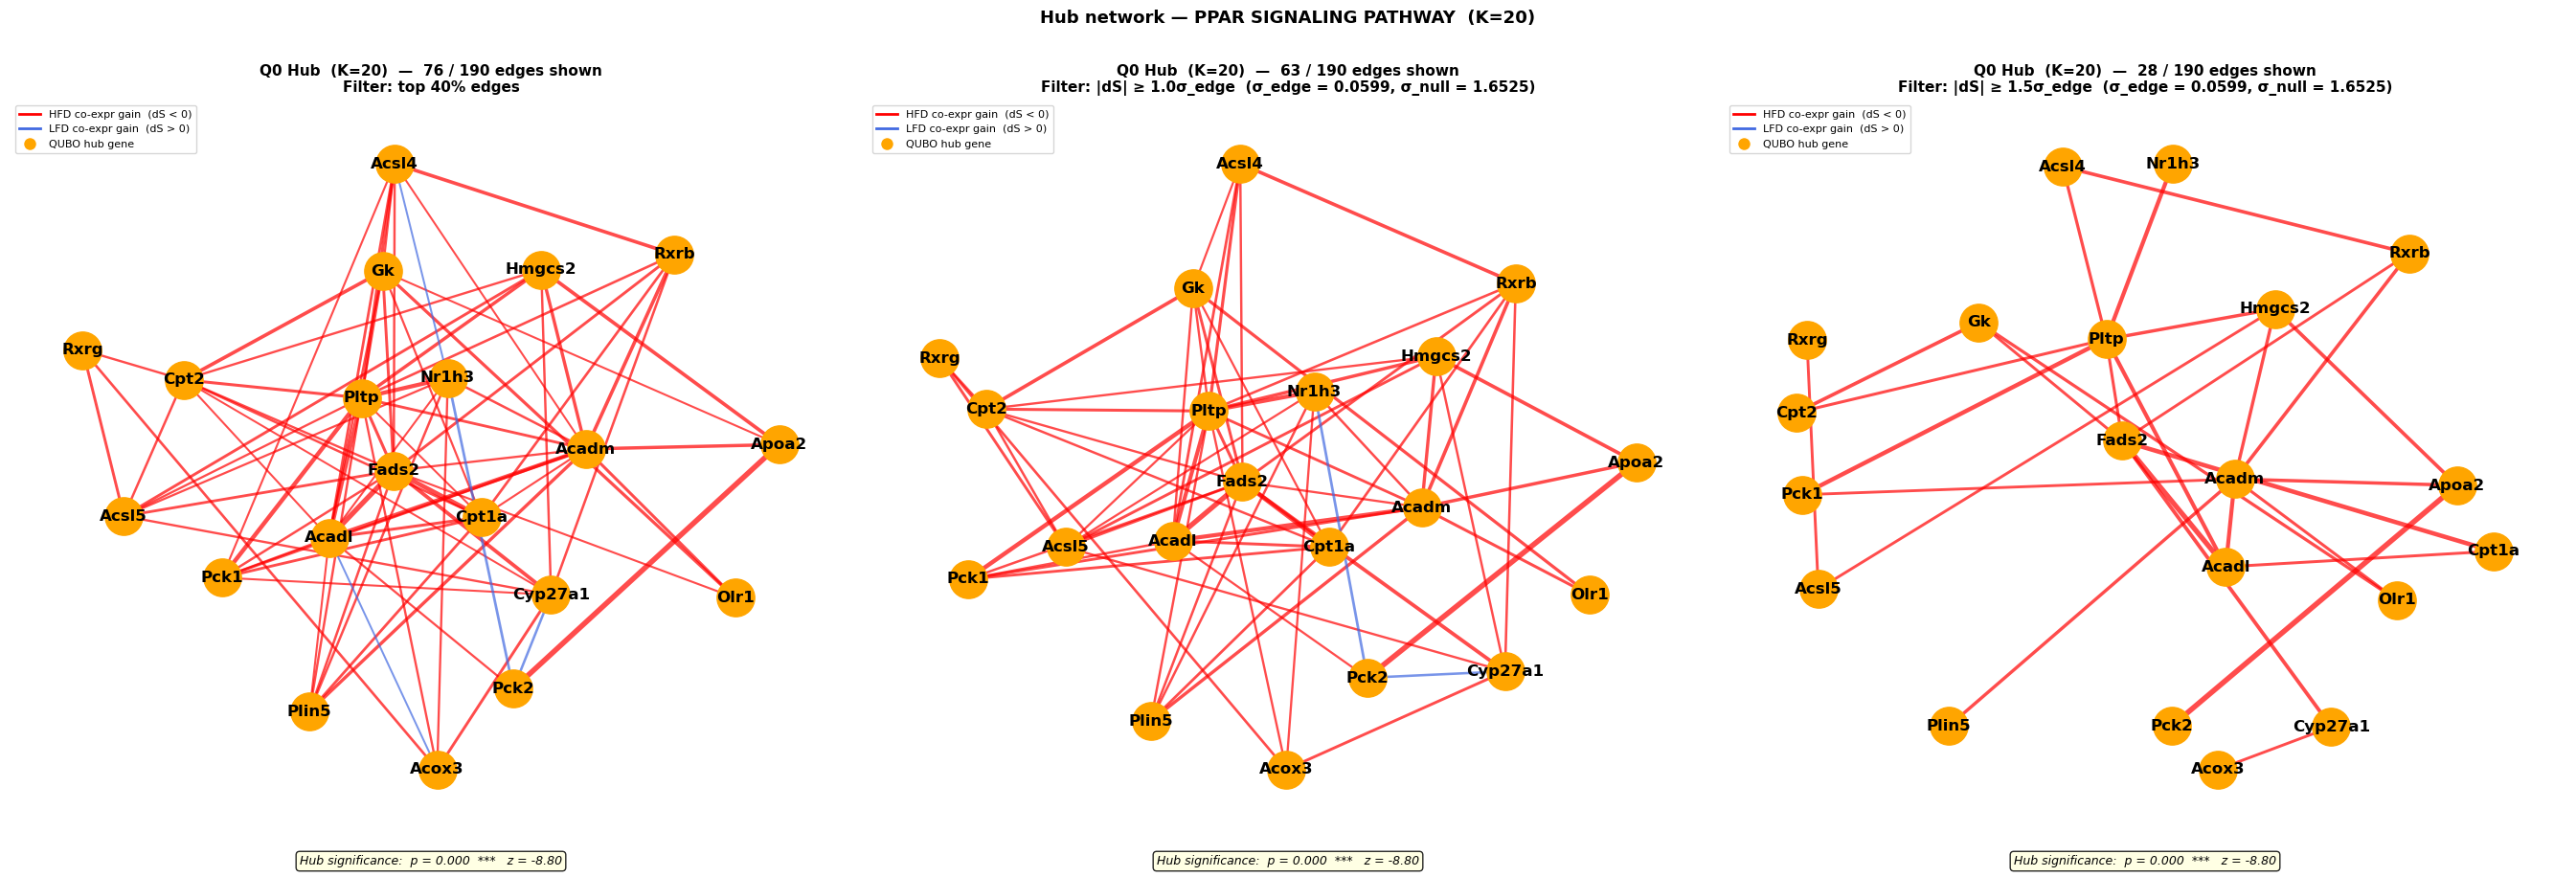

In [22]:
from qubo_dr.plot import plot_hub_network
import matplotlib.pyplot as plt
K = 20
REFERENCE_LABEL = reference_label   # condition B (reference)
TEST_LABEL = test_label
PATHWAY_NAME = pathway_target
# ── Three panels: coarse → stat-informed → fine ──────────────────────────────
#fig, axes = plt.subplots(3, 1, figsize=(10, 15))
fig, axes = plt.subplots(1, 3, figsize=(27, 9))

# Panel 1 — top 40 % of hub edges (quick overview)
plot_hub_network(
    results_cd, top_pct=40,
    test_label=TEST_LABEL, reference_label=REFERENCE_LABEL,
    ax=axes[0]
)

# Panel 2 — statistically principled: edges above 1 null-noise σ
#   σ_edge = std(E_null) / (2 × √(K×(K−1)/2))
#   Requires run_perm_test=True in run_pipeline() (already done above)
plot_hub_network(
    results_cd, n_sigma=1.0,
    test_label=TEST_LABEL, reference_label=REFERENCE_LABEL,
    ax=axes[1]
)

# Panel 3 — stricter: 1.5 σ (fewer, strongest edges only)
plot_hub_network(
    results_cd, n_sigma=1.5,
    test_label=TEST_LABEL, reference_label=REFERENCE_LABEL,
    ax=axes[2]
)

plt.suptitle(f'Hub network — {PATHWAY_NAME}  (K={K})',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


Fetching pathway 'PPAR SIGNALING PATHWAY' [KEGG_2026]
  Found 'PPAR SIGNALING PATHWAY'
  Library: [KEGG_2026]  |  Genes: 76
Classical baseline  |  method='rowsum'  |  K=20
Pathway genes in data: 51/76
Partitioning: 'HFD' (A) vs 'LFD' (B)
  A: 641 cells | B: 1899 cells
  Selected 20 genes (target K=20)
  Genes: ['Angptl4', 'Plin4', 'Cd36', 'Ubc', 'Lpl', 'Pltp', 'Acsl1', 'Acox1', 'Adipoq', 'Fads2', 'Acsl5', 'Sorbs1', 'Acadl', 'Dbi', 'Fabp5', 'Plin2', 'Slc27a1', 'Fabp4', 'Acadm', 'Hmgcs1']
  Saved 20 genes to classical_pathway_genes.txt
Hub significance test (200 permutations)...
  Hub permutation test: 200 perms, K=20 genes, N=2540 cells…
  E_real=-51.3633  null: mean=-0.1483, std=2.7274
  z=-18.78  p=0.0000  ***
Generating plots...
Classical pipeline complete.
QUBO only    (15): ['Acox3', 'Acsl4', 'Apoa2', 'Cpt1a', 'Cpt2', 'Cyp27a1', 'Gk', 'Hmgcs2', 'Nr1h3', 'Olr1', 'Pck1', 'Pck2', 'Plin5', 'Rxrb', 'Rxrg']
Classical only (15): ['Acox1', 'Acsl1', 'Adipoq', 'Angptl4', 'Cd36', 'Dbi', 'Fabp

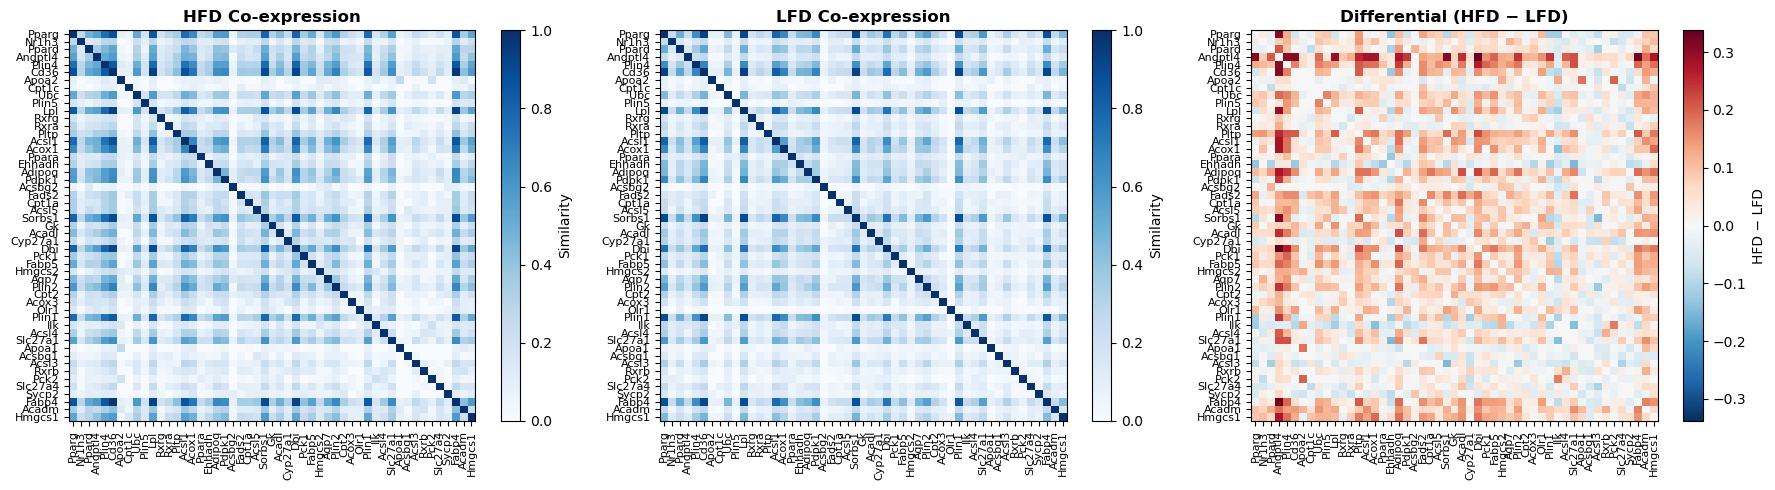

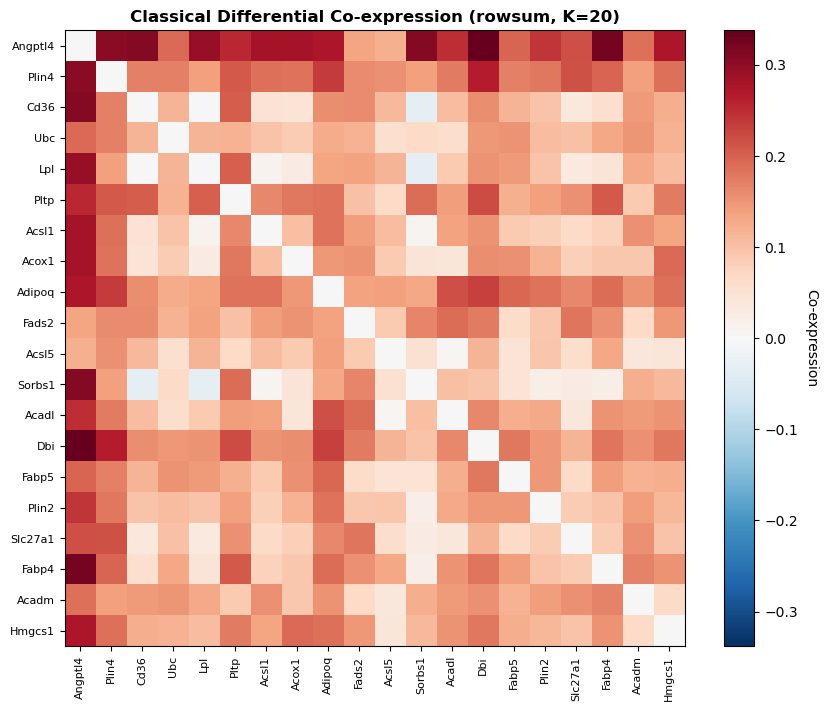

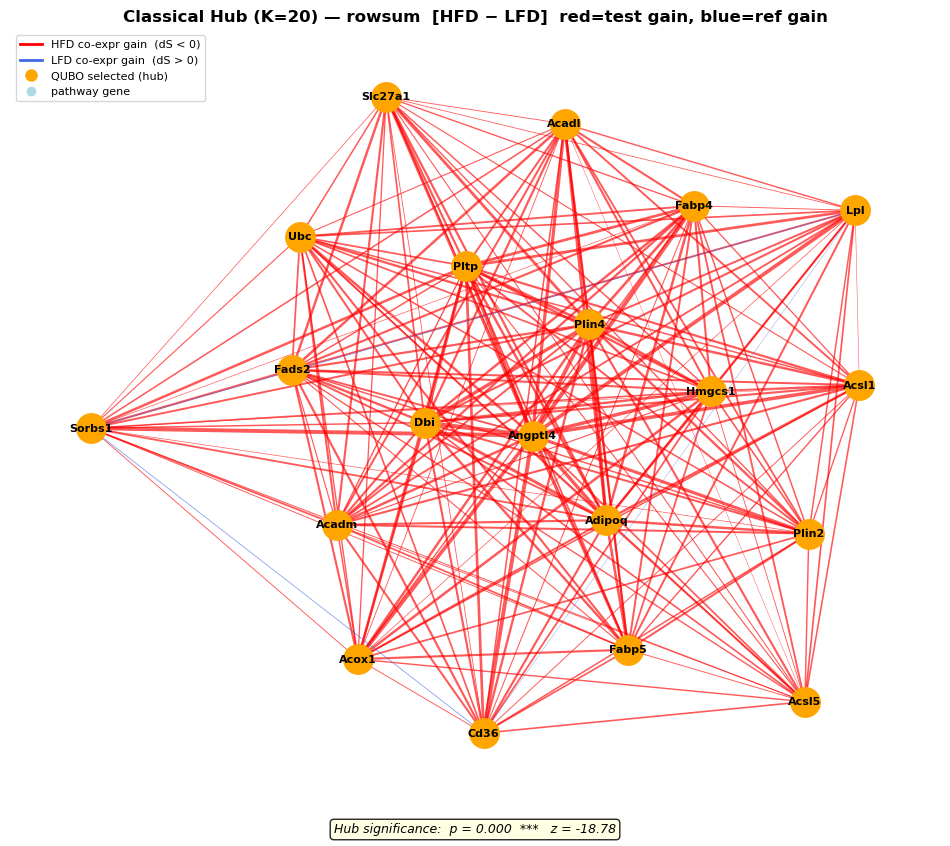

In [24]:
from qubo_dr.pipeline import run_pipeline_classical

# ── Classical baseline — same data, no QUBO ───────────────────────────────
results_cd_classical = run_pipeline_classical(
    X               = X_cd,
    g               = g_cd,
    batch_id        = batch_cd,
    test_label      = test_label,      # condition A
    reference_label = reference_label,      # condition B (reference)
    pathway_name    = pathway_target,
    library         = 'KEGG_2026',    # optional: restricts search to one library (faster)
    K               = 20,
    method          = 'rowsum',     # or 'absrowsum' or 'spectral'
    plotit          = True,
    outfile         = 'classical_pathway_genes.txt',
)

# ── Direct comparison ─────────────────────────────────────────────────────
qubo_genes      = set(results_cd['sub_g_net'])
classical_genes = set(results_cd_classical['sub_g_net'])

print(f"QUBO only    ({len(qubo_genes - classical_genes)}): {sorted(qubo_genes - classical_genes)}")
print(f"Classical only ({len(classical_genes - qubo_genes)}): {sorted(classical_genes - qubo_genes)}")
print(f"Shared       ({len(qubo_genes & classical_genes)}): {sorted(qubo_genes & classical_genes)}")